In [12]:
import pandas as pd

category_ensemble = pd.read_csv('metrics_by_category_ensemble.csv')
category_ma6 = pd.read_csv('metrics_by_category_ma_6.csv')
category_xgboost = pd.read_csv('metrics_by_category_xgboost.csv')
category_sarima = pd.read_csv('metrics_by_category_sarima.csv')
category_tft = pd.read_csv('tft_metrics_by_category.csv')
category_naive = pd.read_csv('metrics_by_category_seasonal_naive.csv')
category_lv = pd.read_csv('metrics_by_category_last_value.csv')


In [14]:
category_tft

,Unnamed: 0.1,Unnamed: 0,MAE,RMSE,sMAPE,WAPE,Category
0,0,0,0.140447,0.171611,1.004328,0.009976,BAGS
1,1,1,0.148464,0.189994,1.074287,0.010649,BARS
2,2,2,0.272096,0.422372,2.096149,0.021678,BITESIZE
3,3,3,0.301242,0.437133,2.172935,0.021583,BOXED CHOCOLATE
4,4,4,0.102419,0.129640,0.770982,0.007594,FRUITY CONFECTIONS
5,5,5,0.190986,0.292002,1.604502,0.015668,GUM
6,6,6,0.135821,0.172711,1.251516,0.012074,IMPULSE FANCY
7,7,7,0.121712,0.159054,1.051895,0.010758,MEDICINAL
8,8,8,0.135974,0.183362,0.895131,0.008912,MINTS
9,9,9,0.143801,0.220593,0.955775,0.009567,TABLETS


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# =========================
# LOAD
# =========================
dfs = {
    "Ensemble": pd.read_csv("metrics_by_category_ensemble.csv"),
    "MA_6": pd.read_csv("metrics_by_category_ma_6.csv"),
    "XGBoost": pd.read_csv("metrics_by_category_xgboost.csv"),
    "SARIMA": pd.read_csv("metrics_by_category_sarima.csv"),
    "TFT": pd.read_csv("tft_metrics_by_category.csv"),
    "Naive": pd.read_csv("metrics_by_category_seasonal_naive.csv"),
    "LastValue": pd.read_csv("metrics_by_category_last_value.csv"),
}

# =========================
# UNIFY
# =========================
all_data = []

for model_name, df in dfs.items():
    df = df.copy()
    df["Model"] = model_name
    all_data.append(df)

df_all = pd.concat(all_data, ignore_index=True)

# =========================
# CLEAN
# =========================
metrics = ["MAE", "RMSE", "sMAPE", "WAPE"]

df_all = df_all.drop(columns=["Row Labels"], errors="ignore")
df_all

,MAE,RMSE,sMAPE,WAPE,Category,Model,Unnamed: 0.1,Unnamed: 0
0,0.408101,0.597995,2.795806,0.027106,TABLETS,Ensemble,NaN,NaN
1,0.495478,0.581216,3.311795,0.032670,TAKE HOME LOOSE KONFETY,Ensemble,NaN,NaN
2,0.585899,0.739805,4.051096,0.040052,BARS,Ensemble,NaN,NaN
3,0.913529,1.027240,6.317850,0.063784,FRUITY CONFECTIONS,Ensemble,NaN,NaN
4,0.957687,1.084028,6.807002,0.068832,BAGS,Ensemble,NaN,NaN
...,...,...,...,...,...,...,...,...
71,3.497784,3.577541,24.153141,0.272726,GUM,LastValue,NaN,NaN
72,4.521595,4.569465,32.284560,0.383138,BITESIZE,LastValue,NaN,NaN
73,4.610968,4.658441,33.028218,0.393693,IMPULSE FANCY,LastValue,NaN,NaN
74,5.271450,5.357941,38.818661,0.476985,MEDICINAL,LastValue,NaN,NaN


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


def plot_metric(df, metric):

    plt.figure(figsize=(16, 7))

    ax = sns.barplot(
        data=df,
        x="Category",
        y=metric,
        hue="Model",
        palette="tab10"
    )

    plt.title(f"{metric} by Category and Model", fontsize=16, weight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric)
    plt.xlabel("Category")

    # =====================================================
    # LABELS ON TOP OF BARS
    # =====================================================
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            fontsize=8,
            padding=2,
            rotation=90
        )

    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

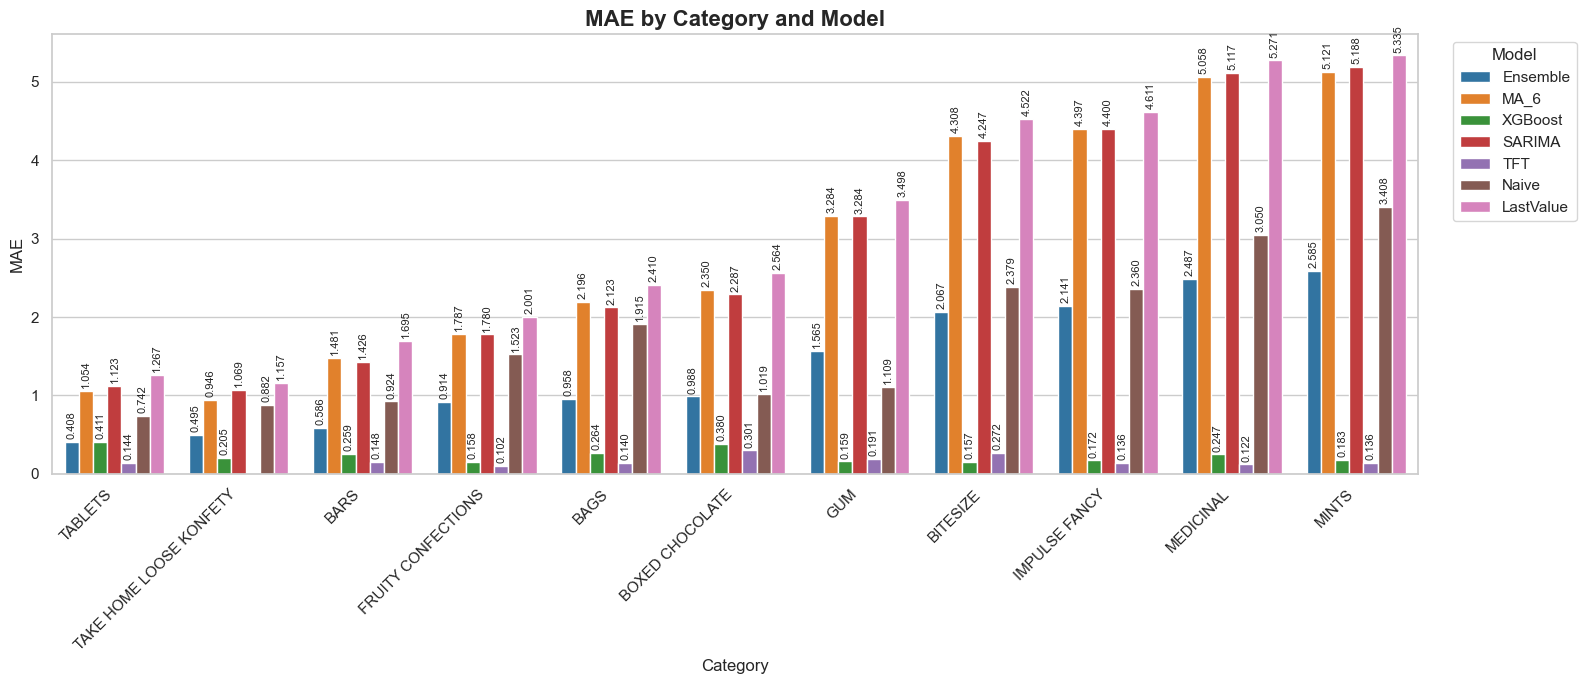

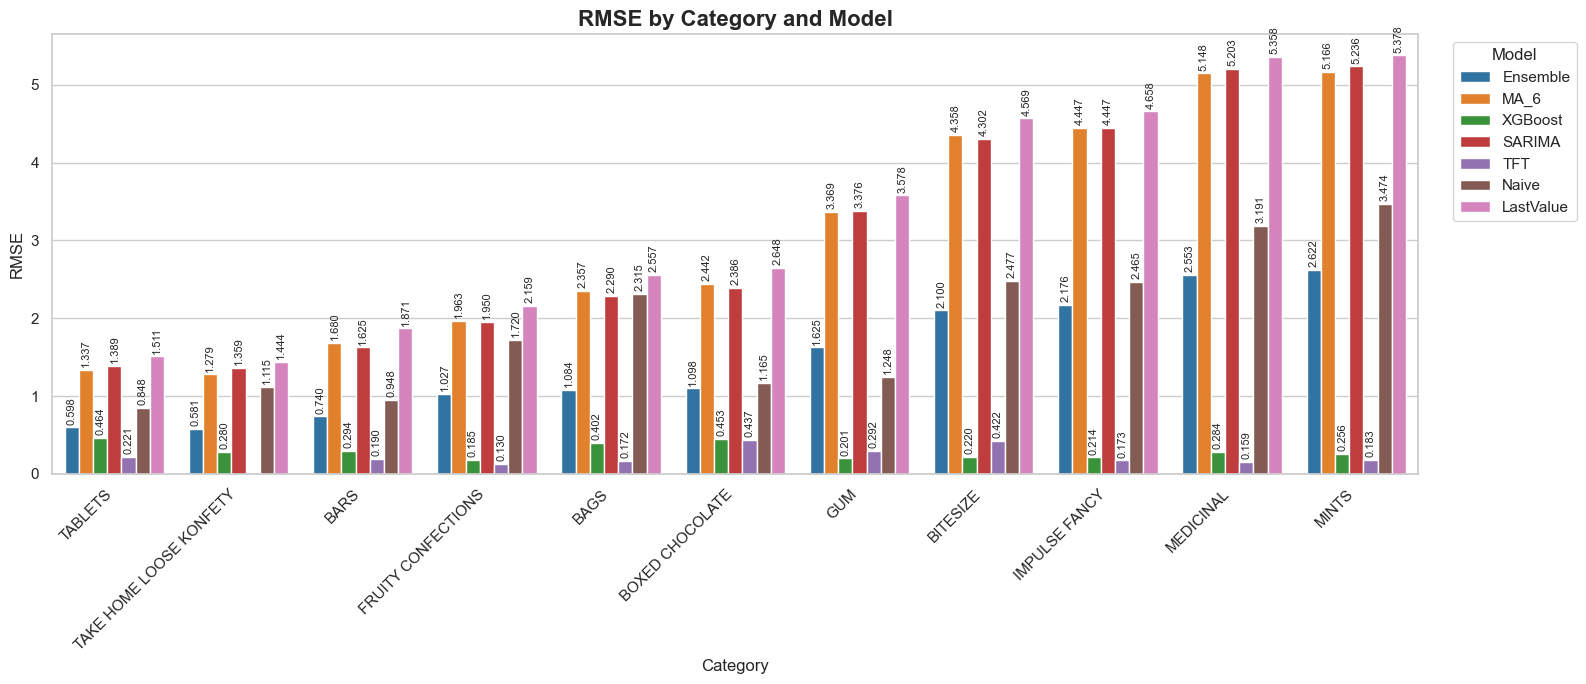

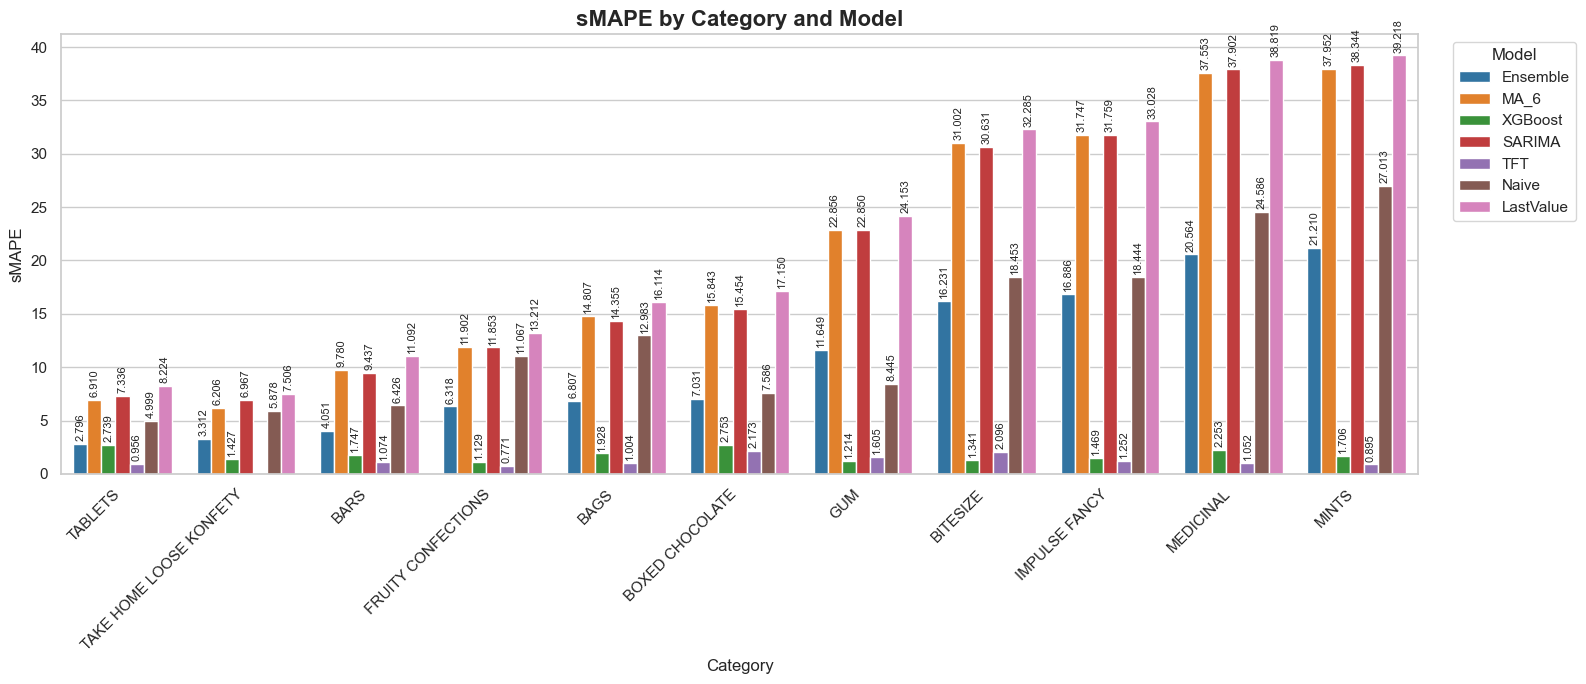

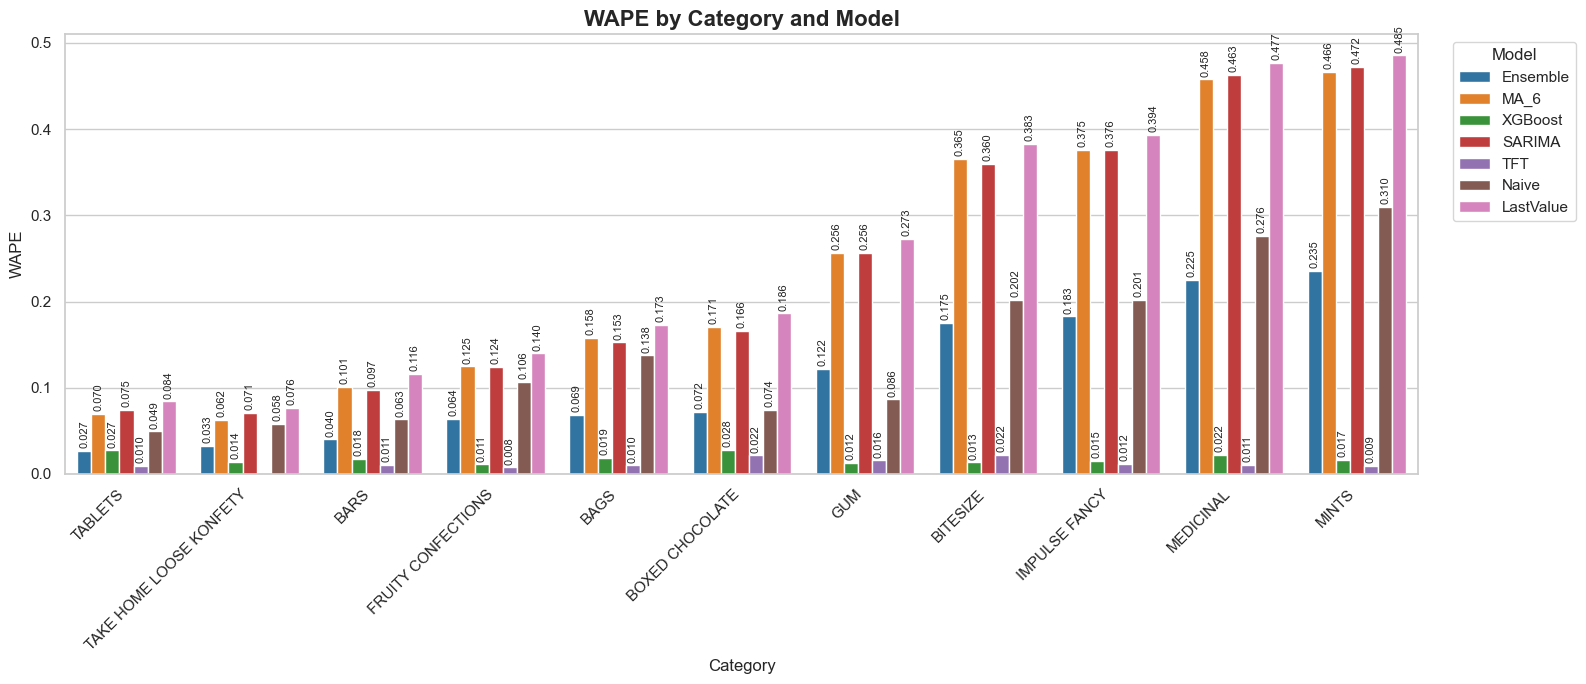

In [21]:
for m in metrics:
    plot_metric(df_all, m)

In [26]:
month_ensemble = pd.read_csv('metrics_by_month_ensemble.csv')
month_ma6 = pd.read_csv('metrics_by_month_ma_6.csv')
month_xgboost = pd.read_csv('metrics_by_month_xgboost.csv')
month_sarima = pd.read_csv('metrics_by_month_sarima.csv')
month_tft = pd.read_csv('tft_metrics_by_month.csv')
month_naive = pd.read_csv('metrics_by_month_seasonal_naive.csv')
month_lv = pd.read_csv('metrics_by_month_last_value.csv')
month_tft

,month,MAE,RMSE,sMAPE,WAPE
0,2024-01,0.142159,0.209260,1.074956,0.010777
1,2024-02,0.139104,0.193674,1.043430,0.010453
2,2024-03,0.183004,0.274121,1.355203,0.013717
3,2024-04,0.129925,0.161966,0.996548,0.009789
4,2024-05,0.210650,0.322383,1.574980,0.015706


In [27]:
month_tft['Month'] = month_tft['month']
month_tft.to_csv('tft_metrics_by_month.csv')

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

dfs = {
    "Ensemble": pd.read_csv("metrics_by_month_ensemble.csv"),
    "MA_6": pd.read_csv("metrics_by_month_ma_6.csv"),
    "XGBoost": pd.read_csv("metrics_by_month_xgboost.csv"),
    "SARIMA": pd.read_csv("metrics_by_month_sarima.csv"),
    "TFT": pd.read_csv("tft_metrics_by_month.csv"),
    "Naive": pd.read_csv("metrics_by_month_seasonal_naive.csv"),
    "LastValue": pd.read_csv("metrics_by_month_last_value.csv"),
}

all_data = []

for model, df in dfs.items():
    df = df.copy()
    df["Model"] = model
    all_data.append(df)

df_all = pd.concat(all_data, ignore_index=True)

metrics = ["MAE", "RMSE", "sMAPE", "WAPE"]

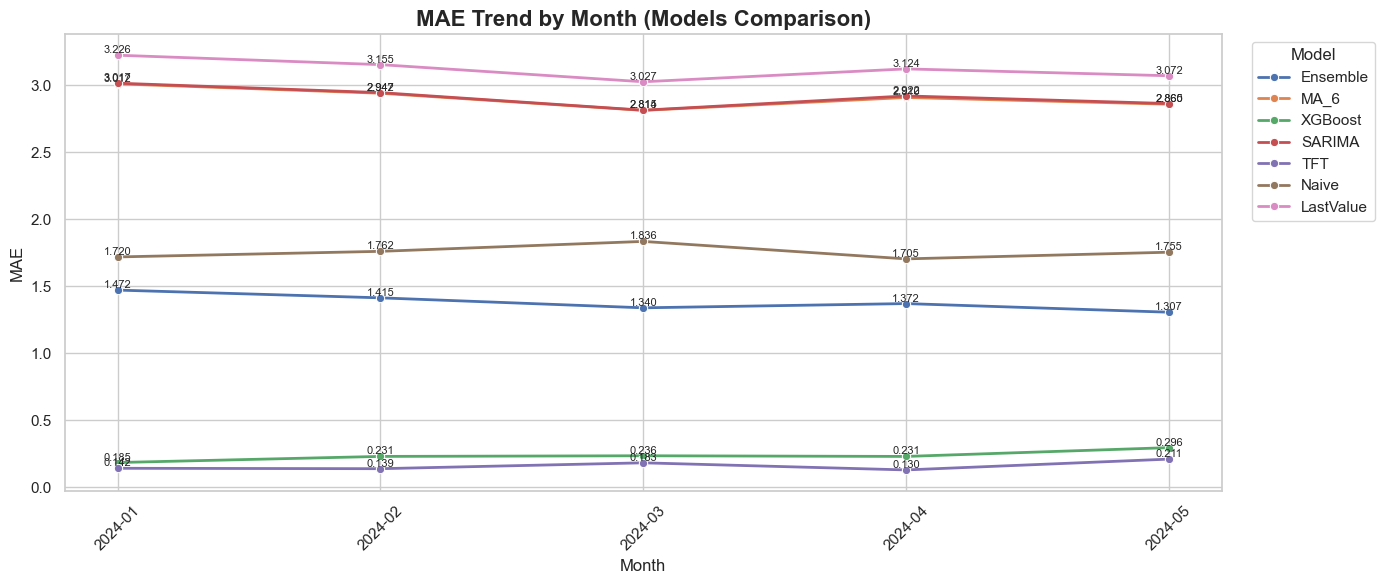

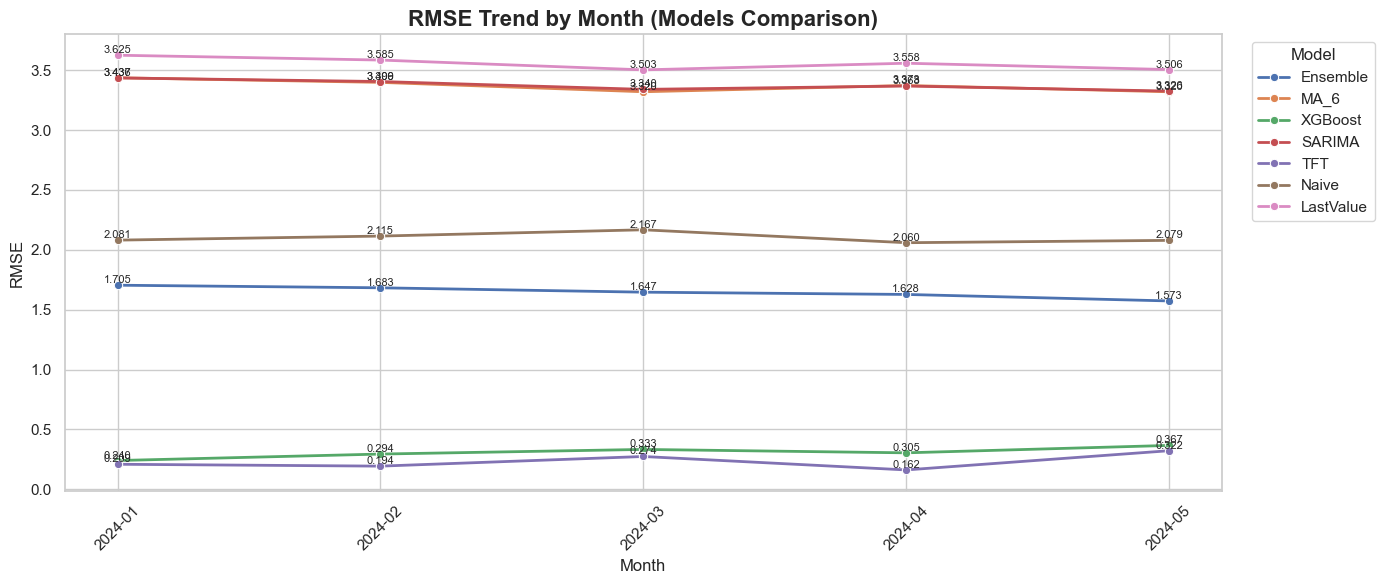

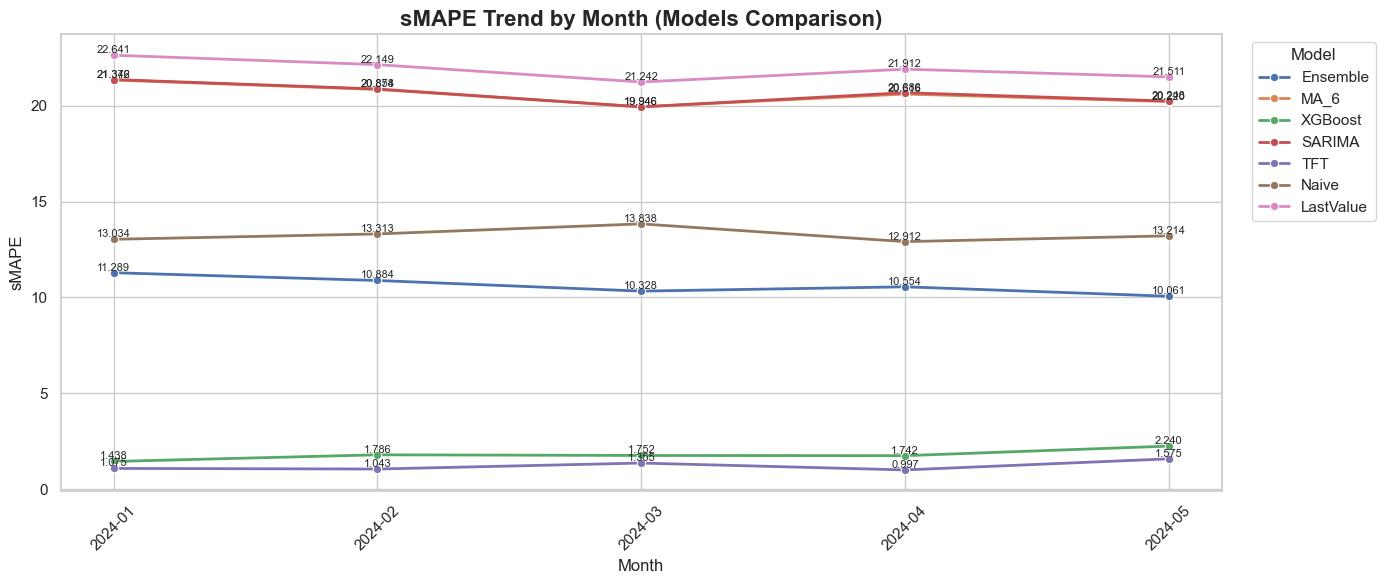

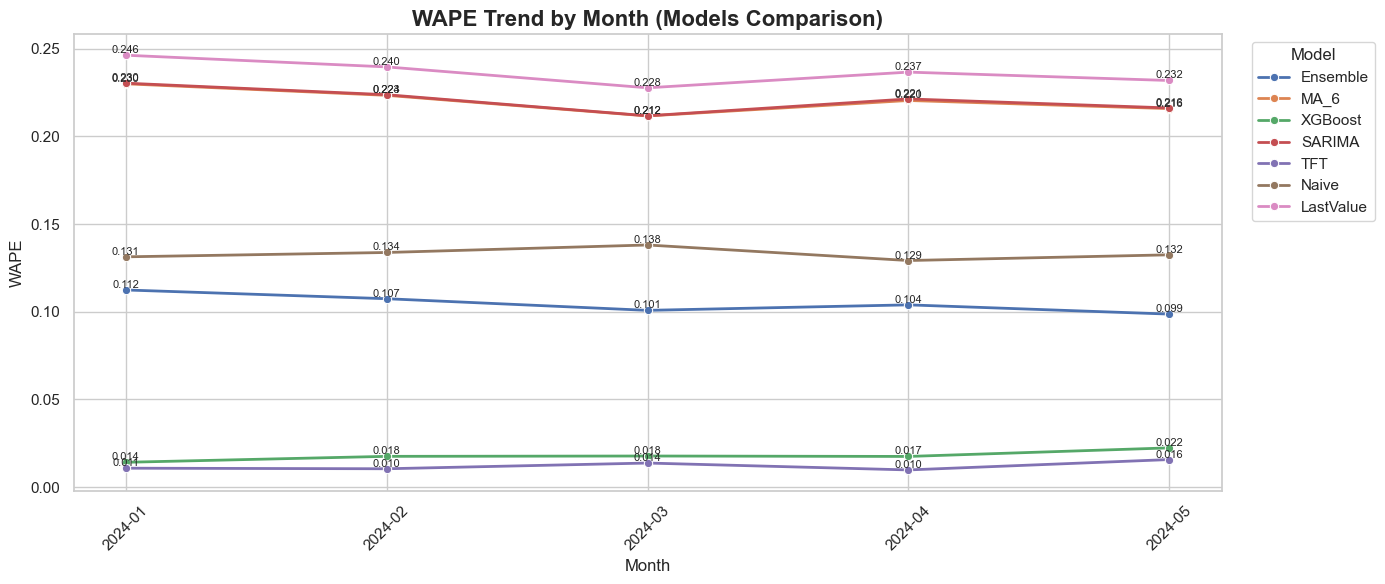

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


def plot_month_trend(metric):

    plt.figure(figsize=(14, 6))

    ax = sns.lineplot(
        data=df_all,
        x="Month",
        y=metric,
        hue="Model",
        marker="o",
        linewidth=2
    )

    plt.title(f"{metric} Trend by Month (Models Comparison)", fontsize=16, weight="bold")
    plt.xlabel("Month")
    plt.ylabel(metric)

    plt.xticks(rotation=45)

    # =========================
    # ADD VALUE LABELS
    # =========================
    for line in ax.lines:
        x_data = line.get_xdata()
        y_data = line.get_ydata()

        for x, y in zip(x_data, y_data):

            # защита от NaN
            if pd.notnull(y):
                ax.text(
                    x,
                    y,
                    f"{y:.3f}",
                    fontsize=8,
                    ha="center",
                    va="bottom"
                )

    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()


for m in metrics:
    plot_month_trend(m)

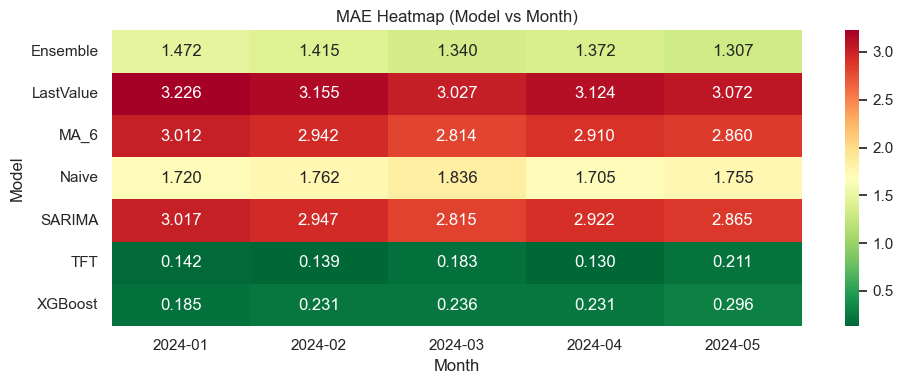

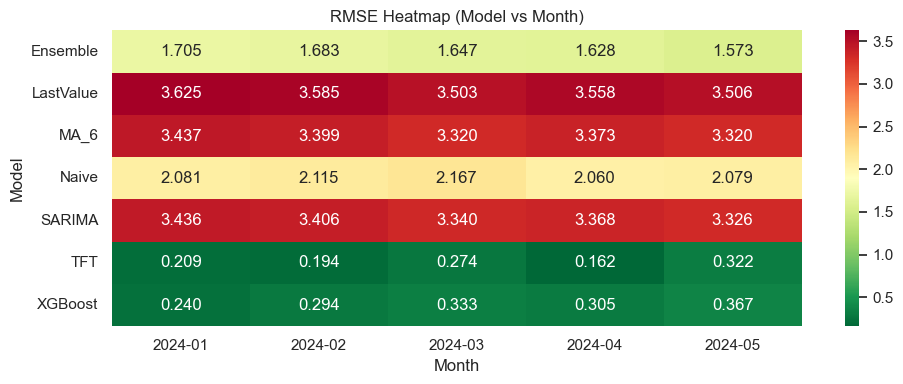

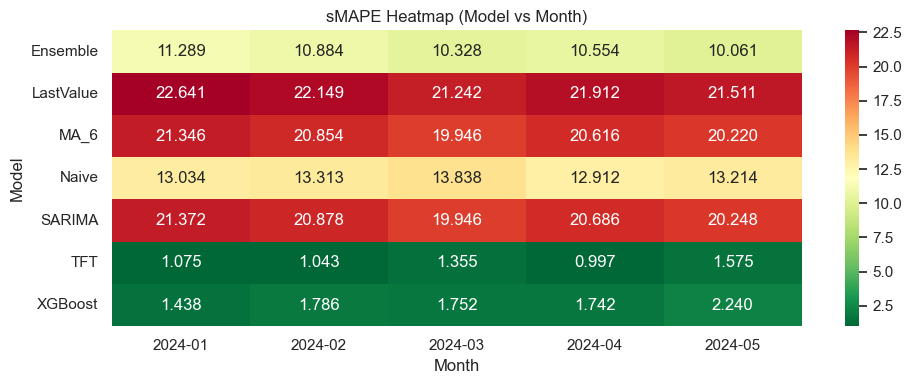

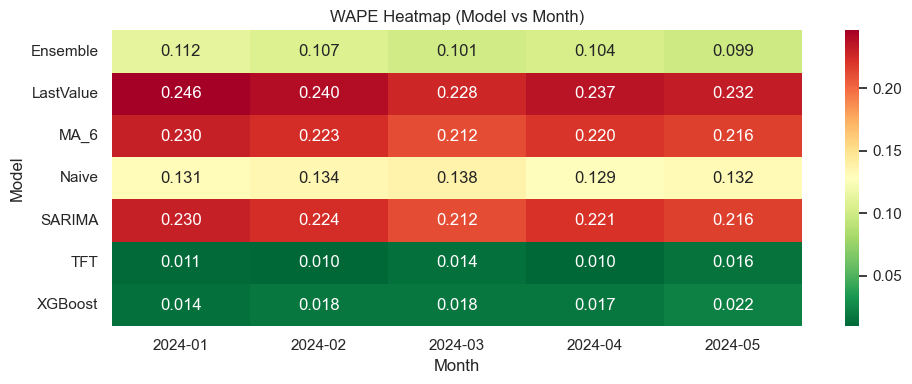

In [31]:
def plot_month_heatmap(metric):

    pivot = df_all.pivot_table(
        index="Model",
        columns="Month",
        values=metric
    )

    plt.figure(figsize=(10, 4))

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn_r"
    )

    plt.title(f"{metric} Heatmap (Model vs Month)")
    plt.tight_layout()
    plt.show()


for m in metrics:
    plot_month_heatmap(m)

In [61]:
df = pd.read_csv('tft_fact_vs_pred.csv')
df = df[df['month'].isin(['2024-01', '2024-02','2024-03','2024-04', '2024-05']) ]
df

,Row Labels,MKT_SDESC,PER_SDESC,MT_Volume KG,NT_CWD,NT_Avg Line,NT_Price per kg,NT_Universe,MT_Universe percent,Frequency,...,Volume per Trip,Year,Month,Month_sin,Month_cos,prediction,target,error,abs_error,month
12,0,0,2024-01-01,14.064728,-0.503382,-0.508513,-0.705592,0.713061,0.791545,-0.118756,...,1.988959,2024,1,0.623175,1.234276e+00,14.111537,14.175140,0.063603,0.063603,2024-01
13,0,0,2024-02-01,14.227574,-0.494436,-0.499925,-0.692251,0.735096,0.844098,-0.118756,...,1.988959,2024,2,1.138552,7.126096e-01,14.104676,14.274537,0.169861,0.169861,2024-02
14,0,0,2024-03-01,14.175140,-0.492918,-0.497623,-0.685064,0.749978,0.849392,-0.118756,...,1.988959,2024,3,1.327194,1.464679e-16,14.134007,14.421309,0.287302,0.287302,2024-03
15,0,0,2024-04-01,14.274537,-0.492103,-0.498139,-0.710405,0.776050,0.860689,-0.118756,...,1.988959,2024,4,1.138552,-7.126096e-01,12.814048,12.788267,-0.025781,0.025781,2024-04
16,0,0,2024-05-01,14.421310,-0.492614,-0.498817,-0.721897,0.782913,0.861765,-0.118756,...,1.988959,2024,5,0.623175,-1.234276e+00,12.811674,13.136740,0.325066,0.325066,2024-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,9,1,2024-03-01,13.762522,3.492721,3.487292,-0.173388,-1.550241,-1.519955,0.205367,...,0.126273,2024,3,1.327194,1.464679e-16,14.889395,14.854933,-0.034462,0.034462,2024-03
644,9,1,2024-04-01,13.548448,3.420968,3.415411,-0.198585,-1.550288,-1.520326,0.205367,...,0.126273,2024,4,1.138552,-7.126096e-01,14.935171,14.909618,-0.025553,0.025553,2024-04
645,9,1,2024-05-01,13.599576,3.483647,3.478202,-0.207038,-1.550288,-1.520449,0.205367,...,0.126273,2024,5,0.623175,-1.234276e+00,16.071320,16.092733,0.021414,0.021414,2024-05
658,9,2,2024-01-01,15.048364,0.229606,0.218585,-0.397137,1.947930,2.052943,2.097366,...,-0.180969,2024,1,0.623175,1.234276e+00,15.989126,15.979985,-0.009141,0.009141,2024-01


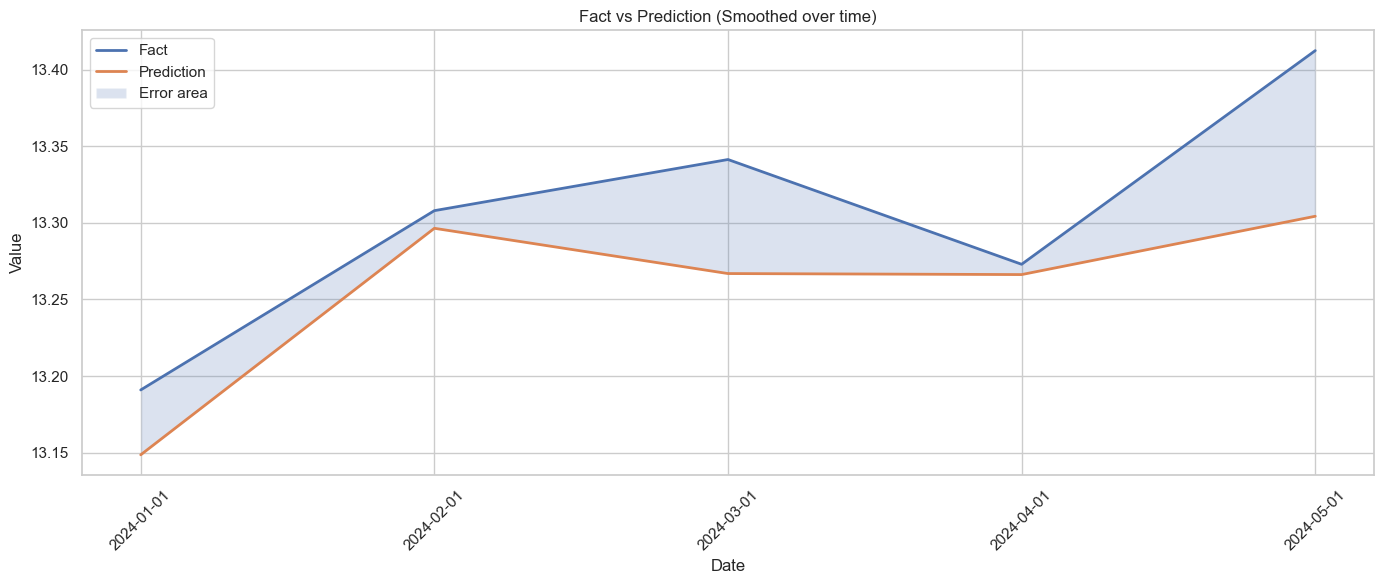

In [62]:
sns.set_theme(style="whitegrid")
# =========================
# AGGREGATE BY DATE
# =========================

daily = df.groupby("PER_SDESC", as_index=False).agg({
    "target": "mean",
    "prediction": "mean",
    "abs_error": "mean"
})

# =========================
# PLOT
# =========================
plt.figure(figsize=(14,6))

plt.plot(daily["PER_SDESC"], daily["target"], label="Fact", linewidth=2)
plt.plot(daily["PER_SDESC"], daily["prediction"], label="Prediction", linewidth=2)

plt.fill_between(
    daily["PER_SDESC"],
    daily["target"],
    daily["prediction"],
    alpha=0.2,
    label="Error area"
)

plt.title("Fact vs Prediction (Smoothed over time)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

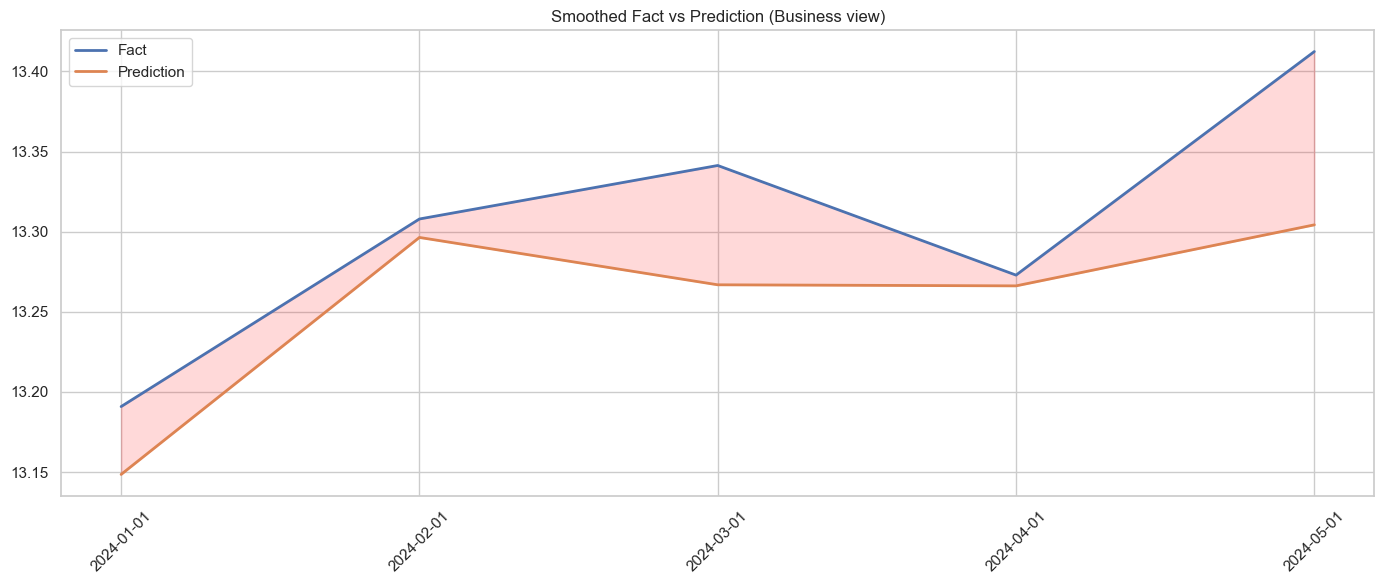

In [63]:
plt.figure(figsize=(14,6))

plt.plot(daily["PER_SDESC"], daily["target"], label="Fact", linewidth=2)
plt.plot(daily["PER_SDESC"], daily["prediction"], label="Prediction", linewidth=2)

plt.fill_between(
    daily["PER_SDESC"],
    daily["target"],
    daily["prediction"],
    color="red",
    alpha=0.15,
)

plt.title("Smoothed Fact vs Prediction (Business view)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [65]:
df = pd.read_csv("ensemble_fact_vs_prediction.csv")
df

,date,actual,prediction,model
0,2024-01-01,14.064728,15.037014,ensemble
1,2024-01-01,14.843393,15.331428,ensemble
2,2024-01-01,12.013523,14.120429,ensemble
3,2024-01-01,14.899717,15.508370,ensemble
4,2024-01-01,12.053617,13.935337,ensemble
...,...,...,...,...
215,2024-05-01,13.333077,14.523164,ensemble
216,2024-05-01,14.953402,15.534175,ensemble
217,2024-05-01,14.904257,15.391296,ensemble
218,2024-05-01,11.675446,13.908644,ensemble


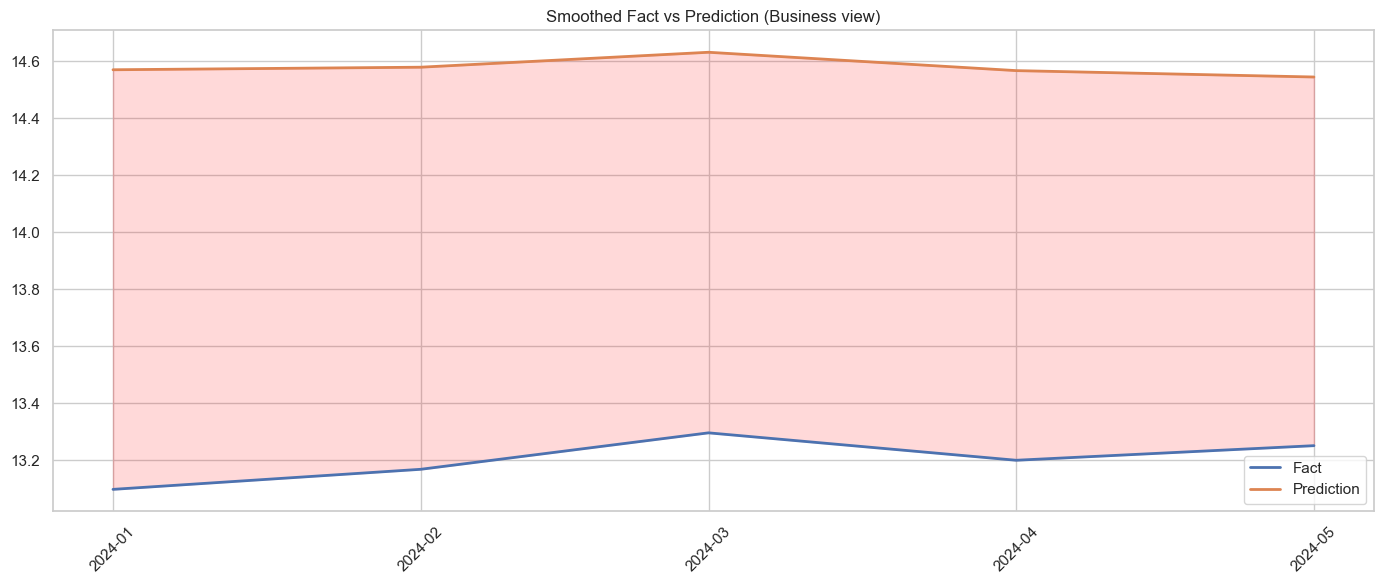

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

sns.set_theme(style="whitegrid")

# =========================
# DATE PARSE
# =========================
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# =========================
# AGGREGATE BY DATE
# =========================
daily = df.groupby("date", as_index=False).agg({
    "actual": "mean",
    "prediction": "mean",
})

daily = daily.sort_values("date")

# =========================
# PLOT
# =========================
plt.figure(figsize=(14, 6))

plt.plot(daily["date"], daily["actual"], label="Fact", linewidth=2)
plt.plot(daily["date"], daily["prediction"], label="Prediction", linewidth=2)

plt.fill_between(
    daily["date"],
    daily["actual"],
    daily["prediction"],
    color="red",
    alpha=0.15,
)

# =========================
# X AXIS = ONLY MONTH STARTS
# =========================
ax = plt.gca()

ax.xaxis.set_major_locator(mdates.MonthLocator())              # только месяцы
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))   # формат

plt.title("Smoothed Fact vs Prediction (Business view)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

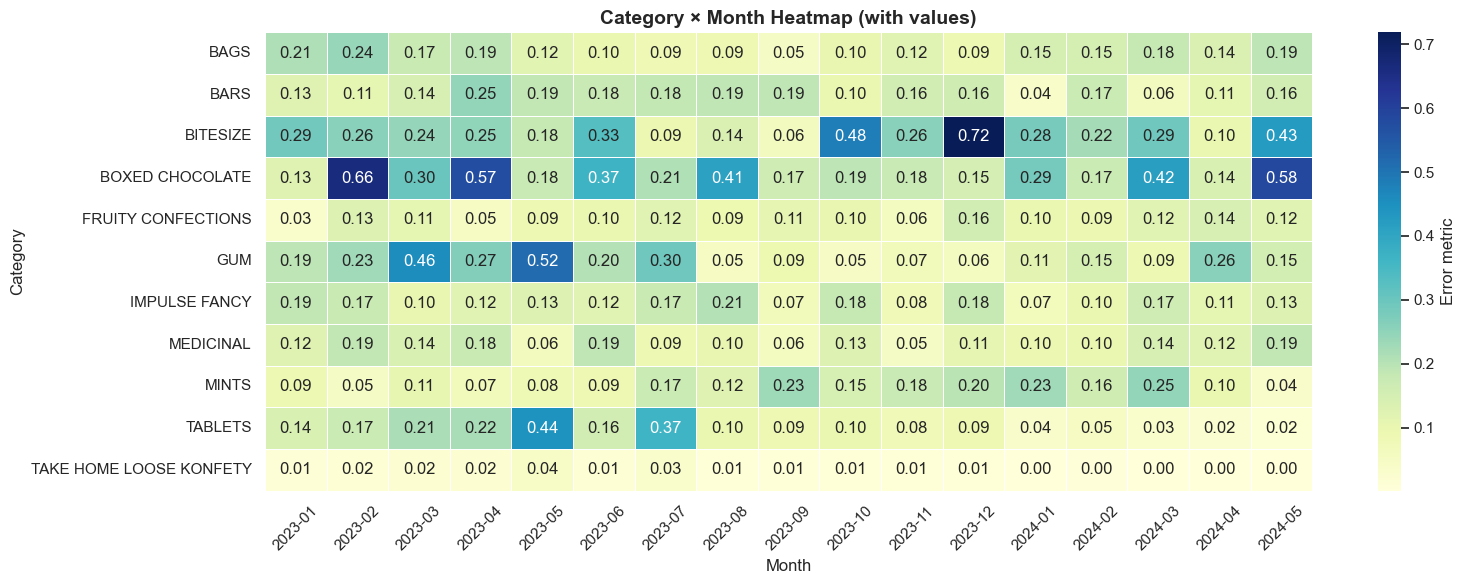

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df = pd.read_csv("tft_heatmap.csv")

category_map = {
    "BAGS": 0,
    "BARS": 1,
    "BITESIZE": 2,
    "BOXED CHOCOLATE": 3,
    "FRUITY CONFECTIONS": 4,
    "GUM": 5,
    "IMPULSE FANCY": 6,
    "MEDICINAL": 7,
    "MINTS": 8,
    "TABLETS": 9,
    "TAKE HOME LOOSE KONFETY": 10
}

inv_map = {v: k for k, v in category_map.items()}

df["Category"] = df["Row Labels"].map(inv_map)
df = df.drop(columns=["Row Labels"])
df = df.set_index("Category")

plt.figure(figsize=(16, 6))

sns.heatmap(
    df,
    annot=True,        # 👈 числа внутри ячеек
    fmt=".2f",         # формат чисел
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Error metric"}
)

plt.title("Category × Month Heatmap (with values)", fontsize=14, weight="bold")
plt.xlabel("Month")
plt.ylabel("Category")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

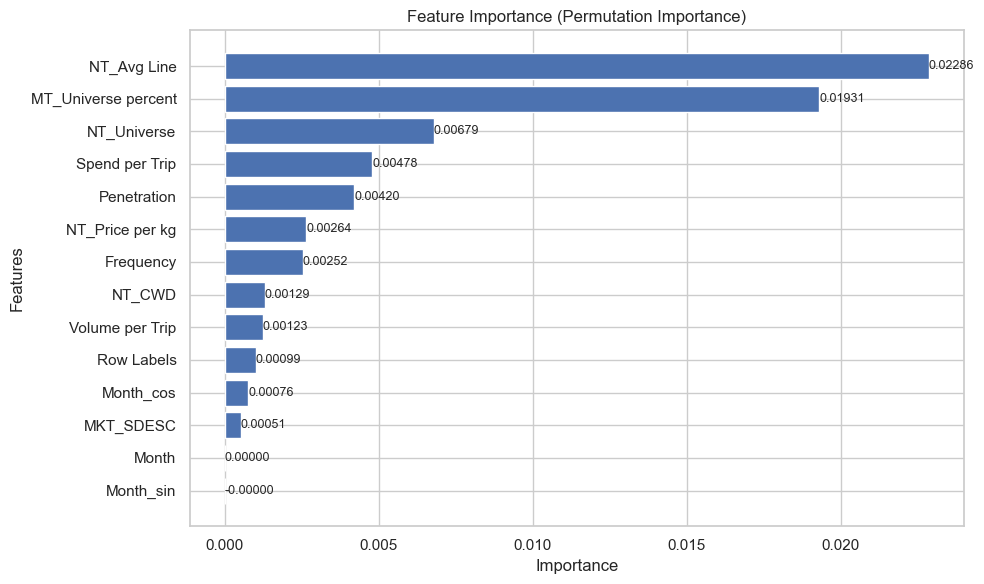

In [72]:
df = pd.read_csv('tft_feature_importance.csv')

df = df.sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(df["feature"], df["importance"])

for bar, value in zip(bars, df["importance"]):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{value:.5f}",
        va="center",
        ha="left",
        fontsize=9
    )

plt.title("Feature Importance (Permutation Importance)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()

plt.show()